RA = 7117.27 N
RB = 8896.63 N

========= RESULTS =========
MAX Von Mises = 226.32 MPa
Critical location = 266.5 mm
Diameter there = 41.275 mm
Factor of Safety = 2.17
✅ SAFE DESIGN


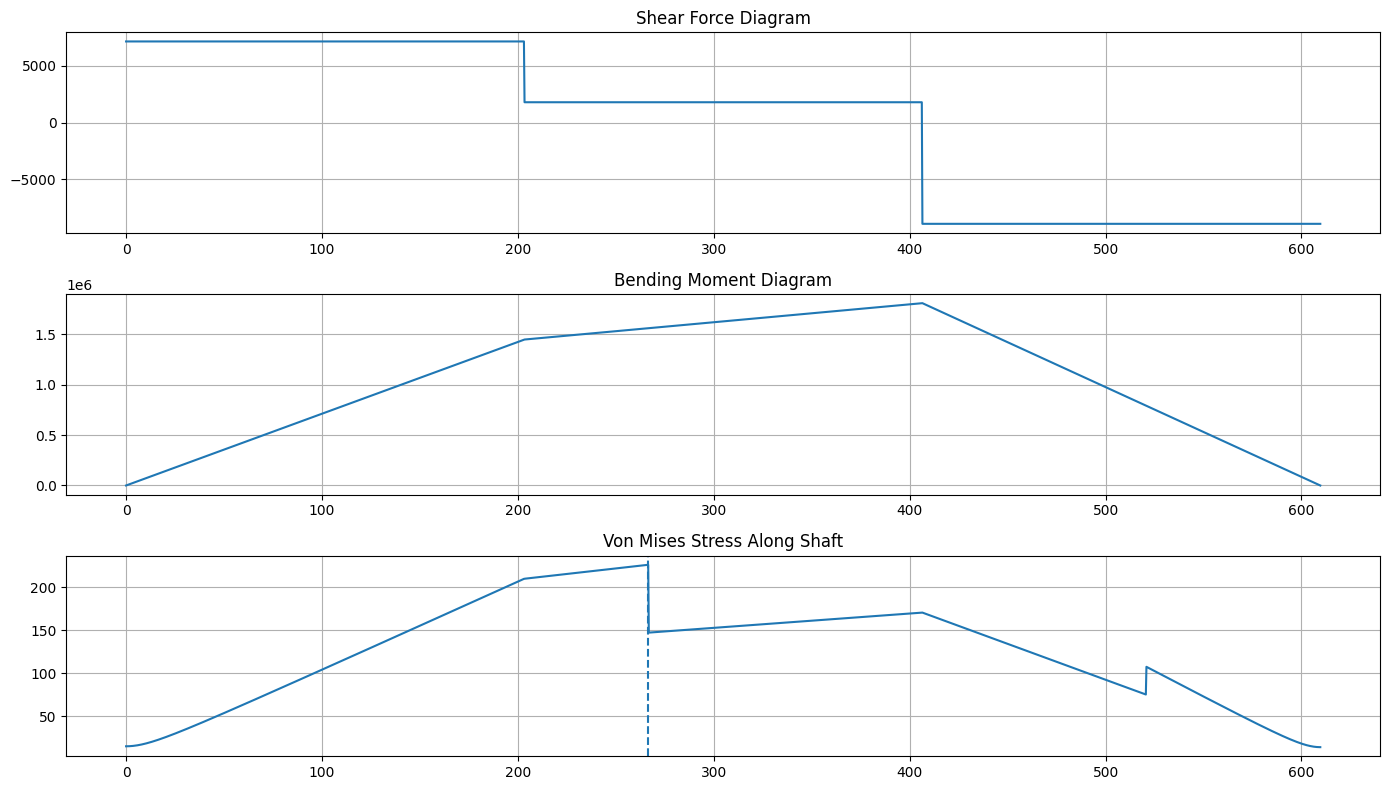

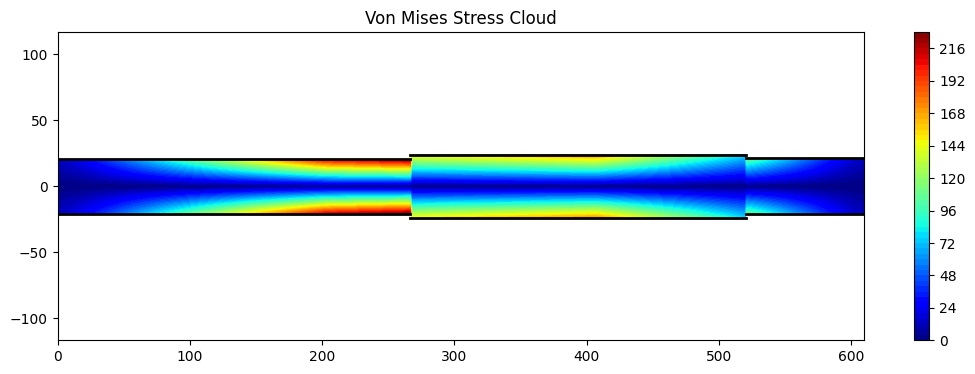

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ======================================================
# 🔥 1. 输入区（考试只改这里）
# ======================================================

L = 609.6  # mm

segments = [
    [0, 266.7, 41.275],
    [266.7, 520.7, 47.625],
    [520.7, 609.6, 42.25]
]

loads = [
    (5337.9, 203.2),
    (10676, 406.4)
]

torques = [
    (120000, 0, L)
]

Sy = 490  # MPa (material yield strength)


# ======================================================
# 🔥 2. 支反力
# ======================================================

def solve_reactions(loads, L):

    total_force = sum(F for F, _ in loads)
    moment_A = sum(F * x for F, x in loads)

    RB = moment_A / L
    RA = total_force - RB

    return RA, RB


RA, RB = solve_reactions(loads, L)

print("RA =", round(RA,2), "N")
print("RB =", round(RB,2), "N")


# ======================================================
# 🔥 3. 工具函数
# ======================================================

def get_diameter(x):
    for s, e, d in segments:
        if s <= x <= e:
            return d
    return None


def bending_moment(x):

    M = RA * x

    for F, pos in loads:
        if x > pos:
            M -= F * (x - pos)

    return M


def shear_force(x):

    V = RA

    for F, pos in loads:
        if x > pos:
            V -= F

    return V


def torque_at_x(x):

    T = 0
    for torque, s, e in torques:
        if s <= x <= e:
            T += torque

    return T


# ======================================================
# 🔥 4. 扫描整个轴（找critical）
# ======================================================

x_vals = np.linspace(0, L, 2000)

VM_max = 0
critical_x = 0
critical_d = 0

VM_list = []
M_list = []
V_list = []

for x in x_vals:

    d = get_diameter(x)
    if d is None:
        VM_list.append(np.nan)
        continue

    I = np.pi * d**4 / 64
    J = np.pi * d**4 / 32
    c = d/2

    M = bending_moment(x)
    T = torque_at_x(x)

    sigma = M * c / I
    tau = T * c / J

    VM = np.sqrt(sigma**2 + 3*tau**2)

    VM_list.append(VM)
    M_list.append(M)
    V_list.append(shear_force(x))

    if VM > VM_max:
        VM_max = VM
        critical_x = x
        critical_d = d


# ======================================================
# 🔥 5. Safety Factor
# ======================================================

FoS = Sy / VM_max

print("\n========= RESULTS =========")
print("MAX Von Mises =", round(VM_max,2), "MPa")
print("Critical location =", round(critical_x,1), "mm")
print("Diameter there =", critical_d, "mm")
print("Factor of Safety =", round(FoS,2))

if FoS < 1:
    print("⚠️ SHAFT WILL YIELD")
else:
    print("✅ SAFE DESIGN")


# ======================================================
# 🔥 6. SFD + BMD（老师最爱）
# ======================================================

plt.figure(figsize=(14,8))

plt.subplot(3,1,1)
plt.plot(x_vals, V_list)
plt.title("Shear Force Diagram")
plt.grid()

plt.subplot(3,1,2)
plt.plot(x_vals, M_list)
plt.title("Bending Moment Diagram")
plt.grid()

plt.subplot(3,1,3)
plt.plot(x_vals, VM_list)
plt.axvline(critical_x, linestyle='--')
plt.title("Von Mises Stress Along Shaft")
plt.grid()

plt.tight_layout()
plt.show()


# ======================================================
# 🔥 7. Von Mises Cloud（加分神器）
# ======================================================

res_x = 600
res_y = 160

x = np.linspace(0, L, res_x)
max_r = max(d for _,_,d in segments)/2
y = np.linspace(-max_r, max_r, res_y)

X, Y = np.meshgrid(x, y)
VM_cloud = np.full_like(X, np.nan)

for i in range(res_x):

    xi = X[0,i]
    d = get_diameter(xi)
    if d is None:
        continue

    I = np.pi*d**4/64
    J = np.pi*d**4/32

    M = bending_moment(xi)
    T = torque_at_x(xi)

    for j in range(res_y):

        yi = Y[j,i]

        if abs(yi) <= d/2:

            sigma = M*yi/I
            tau = T*abs(yi)/J

            VM_cloud[j,i] = np.sqrt(sigma**2 + 3*tau**2)

plt.figure(figsize=(13,4))

cp = plt.contourf(X, Y, VM_cloud, levels=60, cmap='jet')
plt.colorbar(cp)

for s,e,d in segments:
    plt.plot([s,e],[d/2,d/2],'k',lw=2)
    plt.plot([s,e],[-d/2,-d/2],'k',lw=2)

plt.title("Von Mises Stress Cloud")
plt.axis('equal')
plt.show()
